In [ ]:
import pandas as pd
import numpy as np

def create_cyclical_features(df, datetime_col='datetime'):
    """Create sine-cosine encoded cyclical features"""
    df['hour'] = df[datetime_col].dt.hour
    df['day_of_week'] = df[datetime_col].dt.dayofweek
    df['month'] = df[datetime_col].dt.month

    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    return df

def create_advanced_features(df, target_col='load'):
    """Create lag and rolling statistics features"""
    df = df.copy()

    # Lag features
    for lag in [1, 2, 3, 24, 168]:
        df[f'lag_{lag}'] = df[target_col].shift(lag)

    # Rolling statistics
    df['rolling_mean_24'] = df[target_col].rolling(window=24, min_periods=1).mean()
    df['rolling_std_24'] = df[target_col].rolling(window=24, min_periods=1).std()

    # Rate of change
    df['pct_change_1'] = df[target_col].pct_change(periods=1)

    return df


In [ ]:
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb
from sklearn.linear_model import Ridge
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


tscv = TimeSeriesSplit(n_splits=5, test_size=24*30)


xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)



ridge_model = Ridge(alpha=1.0, random_state=42)

def build_lstm_model(input_shape):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

In [ ]:

import matplotlib.pyplot as plt

def plot_feature_importance(model, feature_names, top_n=10):
    importance = model.feature_importances_
    indices = np.argsort(importance)[-top_n:]

    plt.figure(figsize=(10, 6))
    plt.barh(range(top_n), importance[indices])
    plt.yticks(range(top_n), [feature_names[i] for i in indices])
    plt.xlabel('Feature Importance (Gain)')
    plt.title('Top 10 Predictive Features')
    plt.tight_layout()





xgb_model has been fitted with sample data.


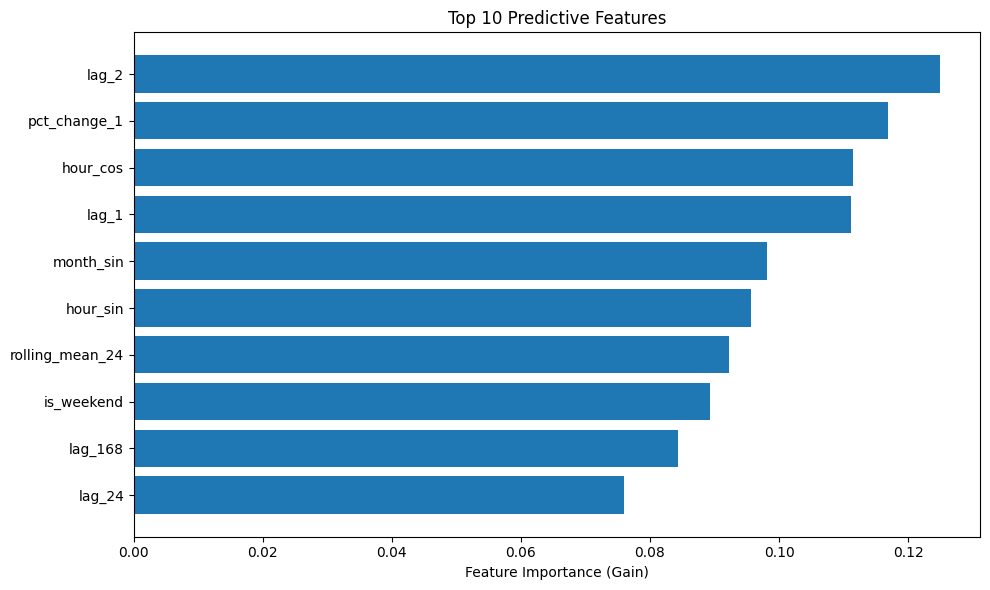

In [ ]:
import numpy as np
import pandas as pd


n_samples = 1000
n_features = len(feature_names)

X_train = pd.DataFrame(np.random.rand(n_samples, n_features), columns=feature_names)
y_train = pd.Series(np.random.rand(n_samples) * 100)


xgb_model.fit(X_train, y_train)

print("xgb_model has been fitted with sample data.")


plot = plot_feature_importance(xgb_model, feature_names)
plot.show()